In [ ]:
# Step 0 — Install dependencies (run once, then restart kernel)
!pip install transformers scikit-learn torch "accelerate>=1.1.0" --quiet

In [1]:
# Step 1 — Custom dataset (40 labelled samples: product/tech reviews)
import pandas as pd
from sklearn.model_selection import train_test_split

custom_data = [
    # POSITIVE
    ("This laptop runs incredibly fast and the battery lasts all day.",           1),
    ("The customer support team resolved my issue within minutes.",               1),
    ("I am blown away by the picture quality of this TV.",                        1),
    ("Shipping was super quick and the packaging was perfect.",                   1),
    ("Absolutely love the new software update, everything feels snappy.",         1),
    ("The restaurant had amazing food and friendly staff.",                       1),
    ("Best purchase I have made all year, totally worth the price.",              1),
    ("The course material is well structured and easy to follow.",                1),
    ("I really enjoyed reading this book, could not put it down.",                1),
    ("The hotel room was clean, spacious, and had a beautiful view.",             1),
    ("Great build quality, the product feels premium in hand.",                   1),
    ("The app works flawlessly on my phone, no crashes at all.",                  1),
    ("Wonderful experience from start to finish, highly recommend.",              1),
    ("The new headphones have outstanding sound and comfort.",                    1),
    ("My kids absolutely love this toy, they play with it every day.",            1),
    ("The seminar was insightful and the speaker was very engaging.",             1),
    ("Delivery arrived ahead of schedule, very impressed.",                       1),
    ("This coffee maker produces the best espresso I have ever tasted.",          1),
    ("The new game mode is incredibly fun and addictive.",                        1),
    ("Excellent value for money, I could not be happier.",                        1),
    # NEGATIVE
    ("The battery dies after just two hours, completely useless.",                0),
    ("Customer service was rude and unhelpful.",                                  0),
    ("The screen cracked after one small drop, terrible quality.",                0),
    ("My order arrived three weeks late and items were damaged.",                 0),
    ("The software update broke half the features I rely on.",                    0),
    ("Food was cold, overpriced, and the waiter ignored us all night.",           0),
    ("Worst product I have ever bought, do not waste your money.",                0),
    ("The instructions are impossible to understand, very frustrating.",          0),
    ("I could not finish the book, it was painfully boring.",                     0),
    ("The room smelled bad and the air conditioning was broken.",                 0),
    ("Flimsy construction, it broke after just one week.",                        0),
    ("The app crashes every time I open it, absolutely dreadful.",                0),
    ("Horrible experience, I will never shop here again.",                        0),
    ("The sound quality is tinny and the fit is uncomfortable.",                  0),
    ("The toy broke on the first day, really disappointed.",                      0),
    ("The presenter was monotone and the content was outdated.",                  0),
    ("The parcel got lost and no one could tell me where it was.",                0),
    ("This coffee machine leaks and is very hard to clean.",                      0),
    ("The new update is full of bugs, unplayable right now.",                     0),
    ("Poor quality for the price, I expected much better.",                       0),
]

df = pd.DataFrame(custom_data, columns=["text", "label"])
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42, stratify=df["label"])
print(f"Train: {len(train_df)}  |  Test: {len(test_df)}")

Train: 30  |  Test: 10


In [2]:
# Step 2 — Evaluate the off-the-shelf model (no fine-tuning)
from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"

ots_pipeline = pipeline("sentiment-analysis", model=MODEL_NAME)

def predict_with_pipeline(pipe, texts):
    results = pipe(texts, truncation=True, max_length=512)
    return [1 if r["label"] == "POSITIVE" else 0 for r in results]

true_labels = test_df["label"].tolist()
ots_preds   = predict_with_pipeline(ots_pipeline, test_df["text"].tolist())

ots_metrics = {
    "Accuracy" : accuracy_score(true_labels, ots_preds),
    "Precision": precision_score(true_labels, ots_preds),
    "Recall"   : recall_score(true_labels, ots_preds),
    "F1-Score" : f1_score(true_labels, ots_preds),
}
print("=== Off-the-Shelf ===")
for k, v in ots_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

C:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 4406.54it/s]


=== Off-the-Shelf ===
  Accuracy  : 0.8000
  Precision : 1.0000
  Recall    : 0.6000
  F1-Score  : 0.7500


In [3]:
# Step 3 — Fine-tune on the custom dataset
import torch
import numpy as np
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            texts, truncation=True, padding="max_length",
            max_length=max_len, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = SentimentDataset(train_df["text"].tolist(), train_df["label"].tolist(), tokenizer)
eval_dataset  = SentimentDataset(test_df["text"].tolist(),  test_df["label"].tolist(),  tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# NOTE: compute_metrics must be defined BEFORE Trainer is created
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy" : accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall"   : recall_score(labels, preds, zero_division=0),
        "f1"       : f1_score(labels, preds, zero_division=0),
    }

training_args = TrainingArguments(
    output_dir="./ft_results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

print("Fine-tuning... (may take ~1-2 min on CPU)")
trainer.train()

Loading weights: 100%|█████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 4211.27it/s]
C:\Python\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Fine-tuning... (may take ~1-2 min on CPU)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.602876,0.800000,1.000000,0.600000,0.750000
2,No log,0.617693,0.800000,1.000000,0.600000,0.750000
3,No log,0.626139,0.800000,1.000000,0.600000,0.750000


C:\Python\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Python\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=12, training_loss=0.07985114057858785, metrics={'train_runtime': 22.4475, 'train_samples_per_second': 4.009, 'train_steps_per_second': 0.535, 'total_flos': 2980516469760.0, 'train_loss': 0.07985114057858785, 'epoch': 3.0})

In [4]:
# Step 4 — Evaluate fine-tuned model
ft_output = trainer.predict(eval_dataset)
ft_preds  = np.argmax(ft_output.predictions, axis=-1)

ft_metrics = {
    "Accuracy" : accuracy_score(true_labels, ft_preds),
    "Precision": precision_score(true_labels, ft_preds, zero_division=0),
    "Recall"   : recall_score(true_labels, ft_preds, zero_division=0),
    "F1-Score" : f1_score(true_labels, ft_preds, zero_division=0),
}
print("=== Fine-Tuned ===")
for k, v in ft_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

C:\Python\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== Fine-Tuned ===
  Accuracy  : 0.8000
  Precision : 1.0000
  Recall    : 0.6000
  F1-Score  : 0.7500


   Metric  Off-the-Shelf  Fine-Tuned  Improvement
 Accuracy           0.80        0.80          0.0
Precision           1.00        1.00          0.0
   Recall           0.60        0.60          0.0
 F1-Score           0.75        0.75          0.0


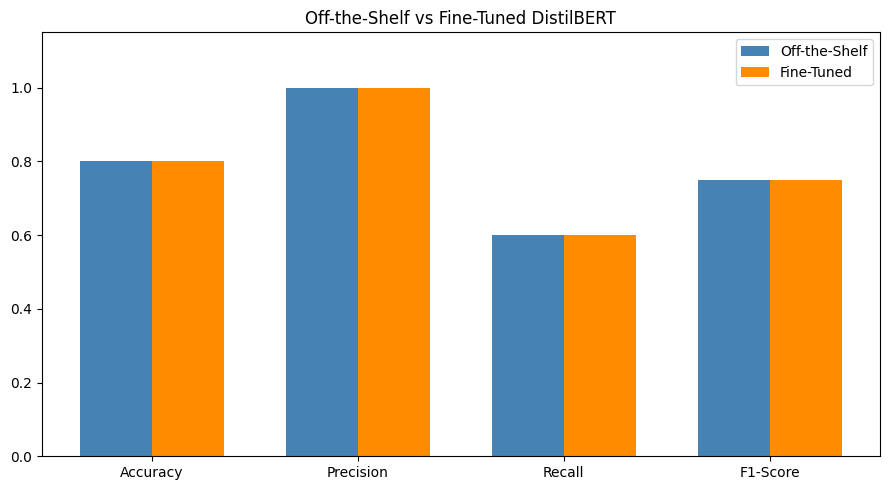

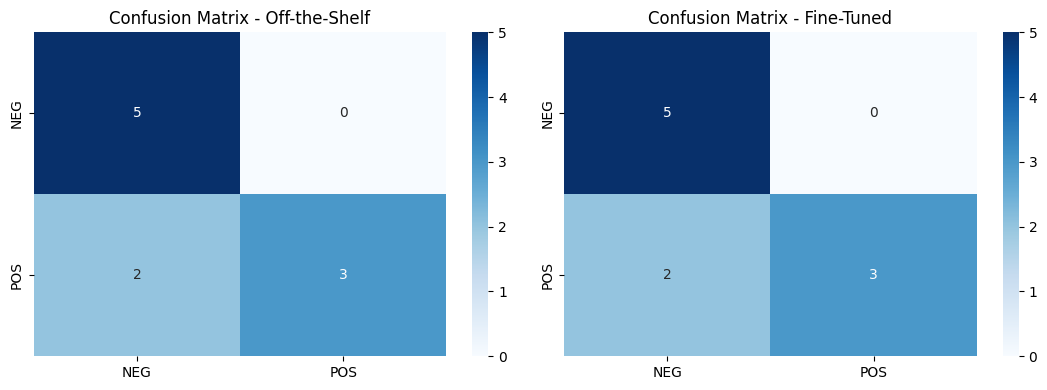

In [5]:
# Step 5 — Compare results
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Comparison table
comparison_df = pd.DataFrame({
    "Metric"        : list(ots_metrics.keys()),
    "Off-the-Shelf" : list(ots_metrics.values()),
    "Fine-Tuned"    : list(ft_metrics.values()),
})
comparison_df["Improvement"] = comparison_df["Fine-Tuned"] - comparison_df["Off-the-Shelf"]
print(comparison_df.to_string(index=False))

# Bar chart
x, width = np.arange(len(ots_metrics)), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, ots_metrics.values(), width, label="Off-the-Shelf", color="steelblue")
ax.bar(x + width/2, ft_metrics.values(),  width, label="Fine-Tuned",    color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(list(ots_metrics.keys()))
ax.set_ylim(0, 1.15)
ax.legend()
ax.set_title("Off-the-Shelf vs Fine-Tuned DistilBERT")
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(axes, [ots_preds, ft_preds], ["Off-the-Shelf", "Fine-Tuned"]):
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["NEG", "POS"], yticklabels=["NEG", "POS"])
    ax.set_title(f"Confusion Matrix - {title}")
plt.tight_layout()
plt.show()

In [ ]:
# Task 2

In [ ]:
Step 0 — Install dependencies
pip install tensorflow tensorflow-datasets scikit-learn matplotlib seaborn

In [7]:
# Step 1 — Load and preprocess the IMDB dataset
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load IMDB dataset
(train_data, test_data), info = tfds.load(
    'imdb_reviews',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True
)

# Tokenize
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts([text.numpy().decode('utf-8') for text, _ in train_data])

# Pad sequences
train_texts = [text.numpy().decode('utf-8') for text, _ in train_data]
test_texts  = [text.numpy().decode('utf-8') for text, _ in test_data]

train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences  = tokenizer.texts_to_sequences(test_texts)

train_padded = pad_sequences(train_sequences, maxlen=120)
test_padded  = pad_sequences(test_sequences,  maxlen=120)

# Extract labels
train_labels = np.array([label.numpy() for _, label in train_data])
test_labels  = np.array([label.numpy() for _, label in test_data])

print(f"Train shape: {train_padded.shape}")
print(f"Test shape : {test_padded.shape}")

Train shape: (25000, 120)
Test shape : (25000, 120)


In [8]:
# Step 2 — Build the LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential([
    Embedding(input_dim=10000, output_dim=16, input_length=120),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

C:\Python\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Step 3 — Build the GRU model
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    Embedding(input_dim=10000, output_dim=16, input_length=120),
    GRU(64),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Step 4 — Train both models
print("Training LSTM model...")
lstm_history = lstm_model.fit(
    train_padded, train_labels,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

print("\nTraining GRU model...")
gru_history = gru_model.fit(
    train_padded, train_labels,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Training LSTM model...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.7657 - loss: 0.4658 - val_accuracy: 0.8538 - val_loss: 0.3422
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8936 - loss: 0.2726 - val_accuracy: 0.8668 - val_loss: 0.3272
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.9216 - loss: 0.2116 - val_accuracy: 0.8624 - val_loss: 0.3351
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.9363 - loss: 0.1794 - val_accuracy: 0.8588 - val_loss: 0.3594
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.9479 - loss: 0.1489 - val_accuracy: 0.8526 - val_loss: 0.4468

Training GRU model...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.7479 - loss: 0.4822 - val_accuracy: 0.8300 - val_loss: 0.3859
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.8870 - loss: 0.2789 - val_accuracy: 0.8584 - val_loss: 0.3324
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/ste

In [11]:
# Step 5 — Evaluate both models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, name):
    preds = (model.predict(test_padded) > 0.5).astype(int)
    return {
        "Model"    : name,
        "Accuracy" : accuracy_score(test_labels, preds),
        "Precision": precision_score(test_labels, preds),
        "Recall"   : recall_score(test_labels, preds),
        "F1-Score" : f1_score(test_labels, preds),
    }

lstm_metrics = evaluate_model(lstm_model, "LSTM")
gru_metrics  = evaluate_model(gru_model,  "GRU")

import pandas as pd
results_df = pd.DataFrame([lstm_metrics, gru_metrics])
print(results_df.to_string(index=False))

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step
Model  Accuracy  Precision  Recall  F1-Score
 LSTM   0.83180   0.878180 0.77048  0.820812
  GRU   0.84264   0.828804 0.86368  0.845883


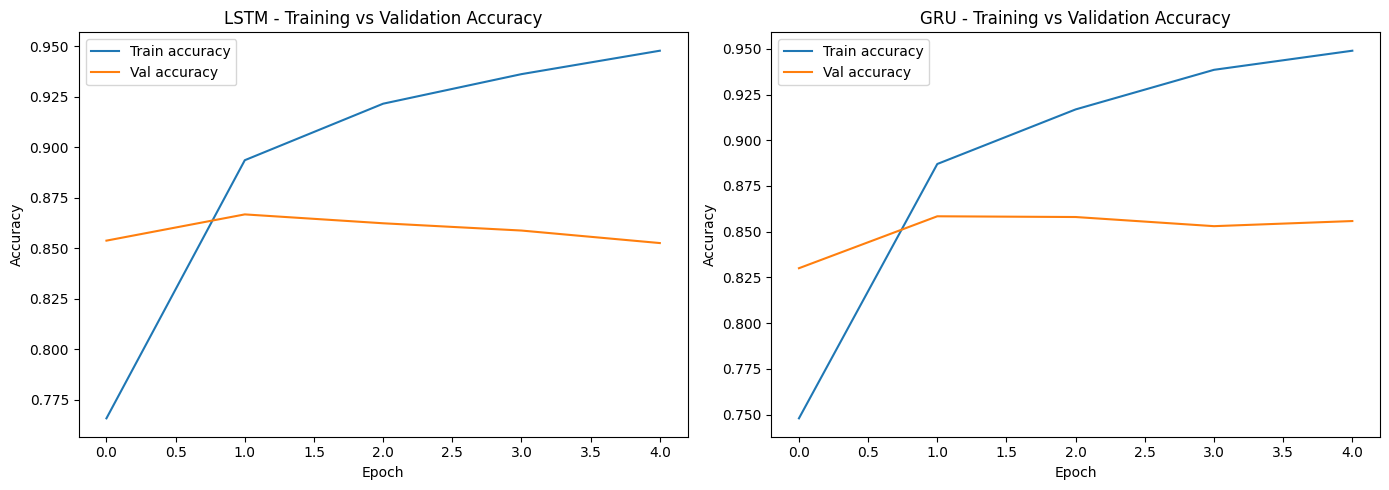

In [12]:
# Step 6 — Compare training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, title in zip(
    axes,
    [lstm_history, gru_history],
    ["LSTM", "GRU"]
):
    ax.plot(history.history['accuracy'],     label='Train accuracy')
    ax.plot(history.history['val_accuracy'], label='Val accuracy')
    ax.set_title(f"{title} - Training vs Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.tight_layout()
plt.show()

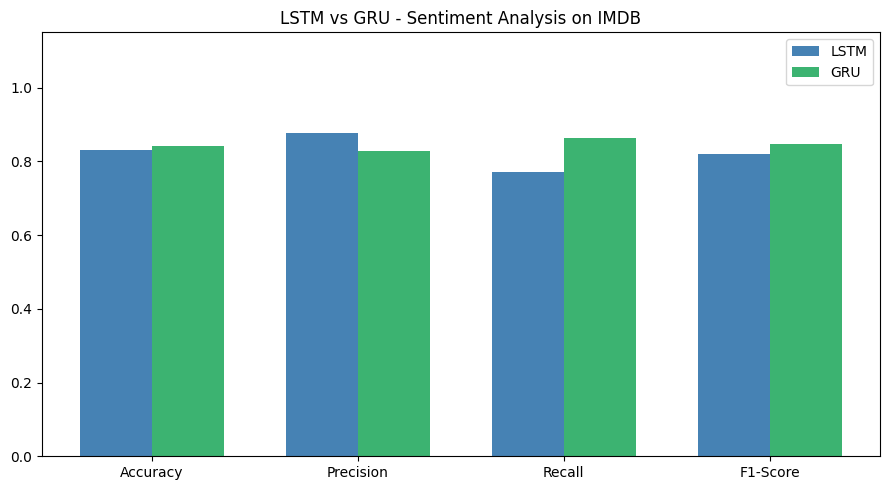

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step


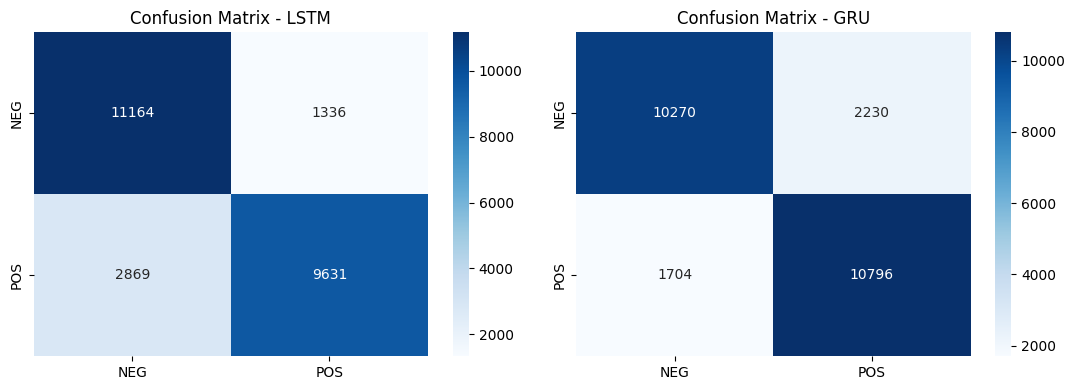

In [13]:
# Step 7 — Compare metrics side by side
import seaborn as sns
from sklearn.metrics import confusion_matrix

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
lstm_vals = [lstm_metrics[m] for m in metrics]
gru_vals  = [gru_metrics[m]  for m in metrics]

x, width = np.arange(len(metrics)), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, lstm_vals, width, label="LSTM", color="steelblue")
ax.bar(x + width/2, gru_vals,  width, label="GRU",  color="mediumseagreen")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()
ax.set_title("LSTM vs GRU - Sentiment Analysis on IMDB")
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, model, title in zip(axes, [lstm_model, gru_model], ["LSTM", "GRU"]):
    preds = (model.predict(test_padded) > 0.5).astype(int)
    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["NEG", "POS"], yticklabels=["NEG", "POS"])
    ax.set_title(f"Confusion Matrix - {title}")
plt.tight_layout()
plt.show()

In [14]:
# Task 3
# install dependancies
terminal --> pip install textblob transformers torch
# Download dataset
terminal --> python -m textblob.download_corpora

In [1]:
# Step 1 — Load the same test samples
import pandas as pd
import numpy as np

# Reusing the same custom dataset from Task 1 for a fair comparison
custom_data = [
    # POSITIVE
    ("This laptop runs incredibly fast and the battery lasts all day.",        1),
    ("The customer support team resolved my issue within minutes.",            1),
    ("I am blown away by the picture quality of this TV.",                     1),
    ("Shipping was super quick and the packaging was perfect.",                1),
    ("Absolutely love the new software update, everything feels snappy.",      1),
    ("The restaurant had amazing food and friendly staff.",                    1),
    ("Best purchase I have made all year, totally worth the price.",           1),
    ("The course material is well structured and easy to follow.",             1),
    ("I really enjoyed reading this book, could not put it down.",             1),
    ("The hotel room was clean, spacious, and had a beautiful view.",          1),
    ("Great build quality, the product feels premium in hand.",                1),
    ("The app works flawlessly on my phone, no crashes at all.",               1),
    ("Wonderful experience from start to finish, highly recommend.",           1),
    ("The new headphones have outstanding sound and comfort.",                 1),
    ("My kids absolutely love this toy, they play with it every day.",         1),
    ("The seminar was insightful and the speaker was very engaging.",          1),
    ("Delivery arrived ahead of schedule, very impressed.",                    1),
    ("This coffee maker produces the best espresso I have ever tasted.",       1),
    ("The new game mode is incredibly fun and addictive.",                     1),
    ("Excellent value for money, I could not be happier.",                     1),
    # NEGATIVE
    ("The battery dies after just two hours, completely useless.",             0),
    ("Customer service was rude and unhelpful.",                               0),
    ("The screen cracked after one small drop, terrible quality.",             0),
    ("My order arrived three weeks late and items were damaged.",              0),
    ("The software update broke half the features I rely on.",                 0),
    ("Food was cold, overpriced, and the waiter ignored us all night.",        0),
    ("Worst product I have ever bought, do not waste your money.",             0),
    ("The instructions are impossible to understand, very frustrating.",       0),
    ("I could not finish the book, it was painfully boring.",                  0),
    ("The room smelled bad and the air conditioning was broken.",              0),
    ("Flimsy construction, it broke after just one week.",                     0),
    ("The app crashes every time I open it, absolutely dreadful.",             0),
    ("Horrible experience, I will never shop here again.",                     0),
    ("The sound quality is tinny and the fit is uncomfortable.",               0),
    ("The toy broke on the first day, really disappointed.",                   0),
    ("The presenter was monotone and the content was outdated.",               0),
    ("The parcel got lost and no one could tell me where it was.",             0),
    ("This coffee machine leaks and is very hard to clean.",                   0),
    ("The new update is full of bugs, unplayable right now.",                  0),
    ("Poor quality for the price, I expected much better.",                    0),
]

df = pd.DataFrame(custom_data, columns=["text", "label"])
true_labels = df["label"].tolist()
print(f"Total samples: {len(df)}")

Total samples: 40


In [2]:
# Step 2 — TextBlob predictions
from textblob import TextBlob

def predict_textblob(texts):
    preds = []
    for text in texts:
        blob = TextBlob(text)
        # polarity > 0 = positive, <= 0 = negative
        preds.append(1 if blob.sentiment.polarity > 0 else 0)
    return preds

textblob_preds = predict_textblob(df["text"].tolist())

# Show polarity scores for each sentence
print(f"{'Polarity':>10}  {'Pred':>5}  {'True':>5}  Text")
print("-" * 80)
for text, pred, true in zip(df["text"], textblob_preds, true_labels):
    polarity = round(TextBlob(text).sentiment.polarity, 3)
    match = "✓" if pred == true else "✗"
    print(f"{polarity:>10}  {pred:>5}  {true:>5}  {match}  {text[:60]}")

  Polarity   Pred   True  Text
--------------------------------------------------------------------------------
       0.2      1      1  ✓  This laptop runs incredibly fast and the battery lasts all d
       0.0      0      1  ✗  The customer support team resolved my issue within minutes.
       0.0      0      1  ✗  I am blown away by the picture quality of this TV.
     0.556      1      1  ✓  Shipping was super quick and the packaging was perfect.
     0.318      1      1  ✓  Absolutely love the new software update, everything feels sn
     0.488      1      1  ✓  The restaurant had amazing food and friendly staff.
      0.65      1      1  ✓  Best purchase I have made all year, totally worth the price.
     0.433      1      1  ✓  The course material is well structured and easy to follow.
     0.172      1      1  ✓  I really enjoyed reading this book, could not put it down.
     0.608      1      1  ✓  The hotel room was clean, spacious, and had a beautiful view
       0.8      1

In [3]:
# Step 3 — DistilBERT off-the-shelf predictions
from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
bert_pipeline = pipeline("sentiment-analysis", model=MODEL_NAME)

def predict_bert(pipe, texts):
    results = pipe(texts, truncation=True, max_length=512)
    return [1 if r["label"] == "POSITIVE" else 0 for r in results]

bert_preds = predict_bert(bert_pipeline, df["text"].tolist())

C:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 4113.26it/s]


In [5]:
# Step 4 — Evaluate all three
def get_metrics(name, preds, true):
    return {
        "Model"    : name,
        "Accuracy" : accuracy_score(true, preds),
        "Precision": precision_score(true, preds, zero_division=0),
        "Recall"   : recall_score(true, preds, zero_division=0),
        "F1-Score" : f1_score(true, preds, zero_division=0),
    }

textblob_metrics = get_metrics("TextBlob",       textblob_preds, true_labels)
bert_metrics     = get_metrics("DistilBERT",     bert_preds,     true_labels)

results_df = pd.DataFrame([textblob_metrics, bert_metrics])
print(results_df.to_string(index=False))

     Model  Accuracy  Precision  Recall  F1-Score
  TextBlob     0.900        0.9    0.90  0.900000
DistilBERT     0.925        1.0    0.85  0.918919


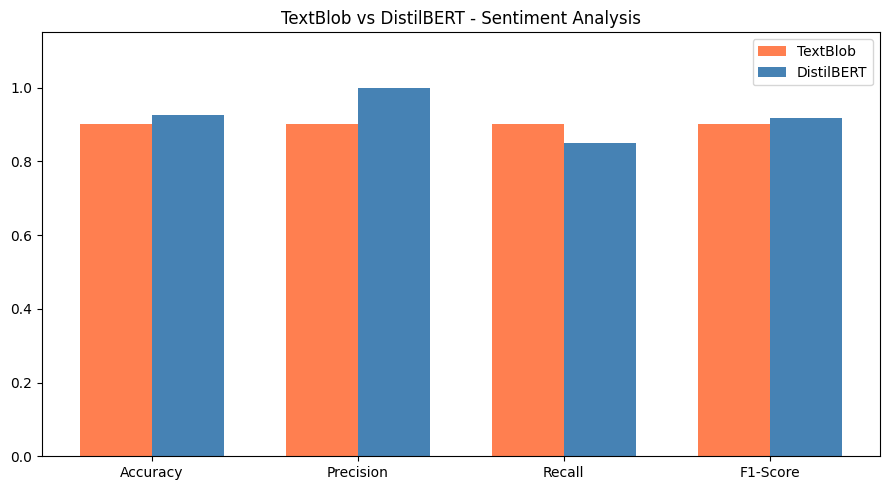

In [6]:
# Step 5 — Bar chart comparison
import matplotlib.pyplot as plt

metrics      = ["Accuracy", "Precision", "Recall", "F1-Score"]
tb_vals      = [textblob_metrics[m] for m in metrics]
bert_vals    = [bert_metrics[m]     for m in metrics]

x, width = np.arange(len(metrics)), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, tb_vals,   width, label="TextBlob",   color="coral")
ax.bar(x + width/2, bert_vals, width, label="DistilBERT", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()
ax.set_title("TextBlob vs DistilBERT - Sentiment Analysis")
plt.tight_layout()
plt.show()

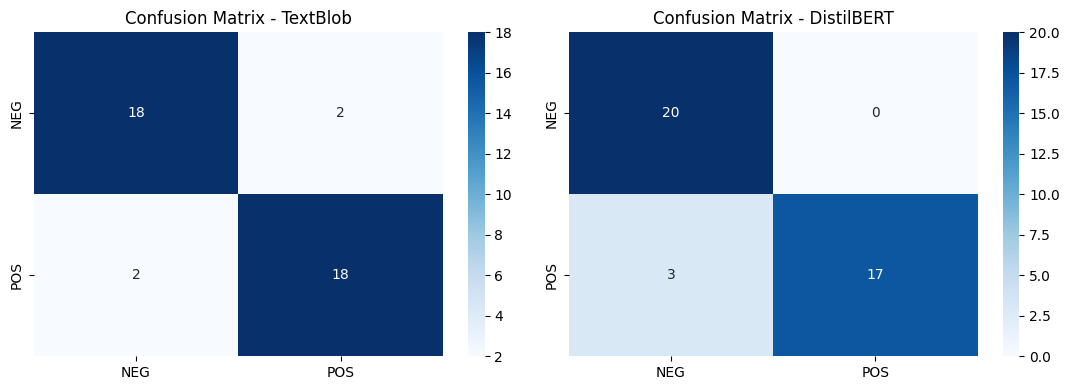

In [7]:
# Step 6 — Confusion matrices
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(
    axes,
    [textblob_preds, bert_preds],
    ["TextBlob", "DistilBERT"]
):
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["NEG", "POS"], yticklabels=["NEG", "POS"])
    ax.set_title(f"Confusion Matrix - {title}")
plt.tight_layout()
plt.show()

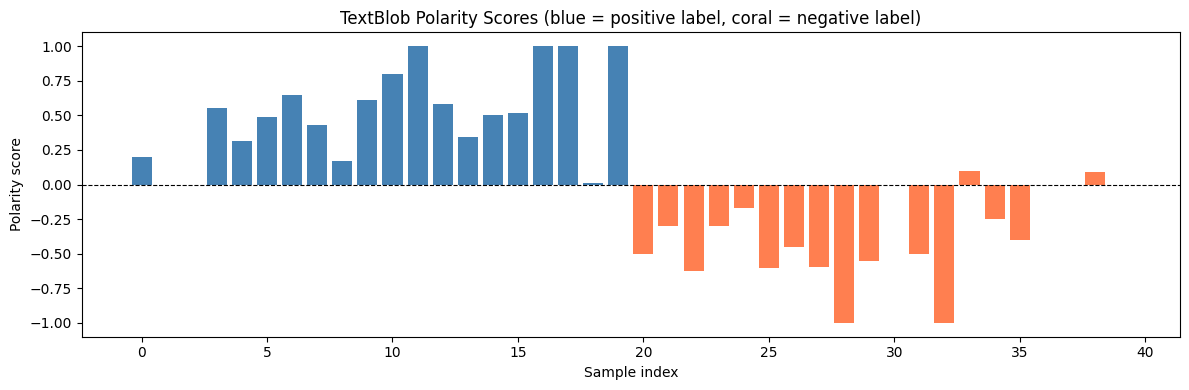

In [8]:
# Step 7 — Polarity distribution (TextBlob only)
polarities  = [TextBlob(text).sentiment.polarity for text in df["text"]]
colors      = ["steelblue" if l == 1 else "coral" for l in true_labels]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(polarities)), polarities, color=colors)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Sample index")
ax.set_ylabel("Polarity score")
ax.set_title("TextBlob Polarity Scores (blue = positive label, coral = negative label)")
plt.tight_layout()
plt.show()